# Neural Networks and Image Classification

**Context:** Guided deep-learning activities, consolidated and extended for portfolio presentation  
**Tools:** Python, TensorFlow/Keras, NumPy, pandas, scikit-learn, Matplotlib, seaborn  
**Methods:** feed-forward neural networks, validation splits,
early stopping, multiclass error analysis, interpolation and extrapolation checks

## TL;DR

**Validated results:** the sine network achieved 0.0377 interpolation RMSE but 1.7004 wide-range extrapolation RMSE; the MNIST Dense classifier reached 97.39% test accuracy; and the compute-conscious CIFAR-10 Dense baseline reached 22.90% accuracy on the full 10,000-image test set. The CIFAR result is a starting baseline, not a competitive image model.

## Context & Methods

This notebook turns three guided activities into one reproducible introduction to neural
networks:

1. approximate a sine function with a small feed-forward regression network;
2. classify MNIST handwritten digits with a Dense network; and
3. establish a compute-conscious Dense baseline for CIFAR-10 colour images.

### Key assumptions and safeguards

- Training, validation, and test partitions serve different purposes. The test partitions
  are used only for final evaluation.
- Input scaling is learned from training data where a fitted scaler is required.
- Integer labels and sparse categorical cross-entropy avoid unnecessary one-hot copies.
- Early stopping monitors validation loss and restores the best recorded weights.
- Fixed random seeds improve repeatability, while minor hardware-dependent differences remain.
- Accuracy is paired with confusion matrices, per-class recall, and visible error examples.
- Neural-network results depend on hardware, TensorFlow version, and stochastic optimisation;
  small last-decimal differences can occur across environments.

The datasets are educational benchmarks. These models are not production systems.

## Setup and References

The datasets load through TensorFlow/Keras and are not stored in this repository.

References:

- [TensorFlow: basic image classification](https://www.tensorflow.org/tutorials/keras/classification)
- [TensorFlow: convolutional neural network tutorial](https://www.tensorflow.org/tutorials/images/cnn)
- [TensorFlow Datasets: MNIST](https://www.tensorflow.org/datasets/catalog/mnist)
- [TensorFlow Datasets: CIFAR-10](https://www.tensorflow.org/datasets/catalog/cifar10)
- [Guided deep-learning tutorial used as the starting point](https://github.com/APMonitor/dynopt/blob/master/DeepLearning.ipynb)

The supplied AWS and Azure documents contain setup links and account instructions, not
completed experiments or exported results. This project therefore makes no cloud-training,
deployment, AWS, or Azure implementation claim.

In [1]:
import os

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "8")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import tensorflow as tf
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    log_loss,
    recall_score,
    root_mean_squared_error,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow import keras
from tensorflow.keras import layers

RANDOM_STATE = 42
keras.utils.set_random_seed(RANDOM_STATE)

pd.set_option("display.precision", 4)
sns.set_theme(style="whitegrid", context="notebook")

print(f"TensorFlow version: {tf.__version__}")
print(f"scikit-learn version: {sklearn.__version__}")
print("Compute devices:", [device.device_type for device in tf.config.list_physical_devices()])

TensorFlow version: 2.19.1
scikit-learn version: 1.9.0
Compute devices: ['CPU']


## Study 1 - Feed-forward Regression on a Sine Function

In [2]:
# Create observations only inside [0, 2π].
x_observed = np.linspace(0.0, 2.0 * np.pi, 100, dtype=np.float32).reshape(-1, 1)
y_observed = np.sin(x_observed).astype(np.float32)

x_reg_train, x_reg_validation, y_reg_train, y_reg_validation = train_test_split(
    x_observed,
    y_observed,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

x_scaler = MinMaxScaler(feature_range=(-1, 1)).fit(x_reg_train)
y_scaler = MinMaxScaler(feature_range=(-1, 1)).fit(y_reg_train)

x_reg_train_scaled = x_scaler.transform(x_reg_train)
x_reg_validation_scaled = x_scaler.transform(x_reg_validation)
y_reg_train_scaled = y_scaler.transform(y_reg_train)
y_reg_validation_scaled = y_scaler.transform(y_reg_validation)

print("Training rows:", len(x_reg_train))
print("Validation rows:", len(x_reg_validation))
print("Observed x range:", (float(x_observed.min()), float(x_observed.max())))

Training rows: 80
Validation rows: 20
Observed x range: (0.0, 6.2831854820251465)


In [3]:
regression_model = keras.Sequential(
    [
        keras.Input(shape=(1,)),
        layers.Dense(32, activation="tanh"),
        layers.Dense(32, activation="tanh"),
        layers.Dense(1),
    ],
    name="sine_regressor",
)
regression_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01), loss="mse")

regression_history = regression_model.fit(
    x_reg_train_scaled,
    y_reg_train_scaled,
    validation_data=(x_reg_validation_scaled, y_reg_validation_scaled),
    epochs=1_000,
    batch_size=16,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=80,
            min_delta=1e-6,
            restore_best_weights=True,
        )
    ],
    verbose=0,
)

print("Trainable parameters:", regression_model.count_params())
print("Epochs completed:", len(regression_history.history["loss"]))
print("Best validation MSE (scaled):", min(regression_history.history["val_loss"]))

Trainable parameters: 1153
Epochs completed: 209
Best validation MSE (scaled): 0.001814384711906314


In [4]:
x_interpolation = np.linspace(0.0, 2.0 * np.pi, 300, dtype=np.float32).reshape(-1, 1)
x_extrapolation = np.linspace(-2.0 * np.pi, 4.0 * np.pi, 600, dtype=np.float32).reshape(-1, 1)

def predict_original_scale(x_values):
    scaled_predictions = regression_model.predict(x_scaler.transform(x_values), verbose=0)
    return y_scaler.inverse_transform(scaled_predictions)


y_interpolation_prediction = predict_original_scale(x_interpolation)
y_extrapolation_prediction = predict_original_scale(x_extrapolation)

interpolation_rmse = root_mean_squared_error(
    np.sin(x_interpolation), y_interpolation_prediction
)
extrapolation_rmse = root_mean_squared_error(
    np.sin(x_extrapolation), y_extrapolation_prediction
)

pd.Series(
    {
        "interpolation_rmse": interpolation_rmse,
        "wide_range_extrapolation_rmse": extrapolation_rmse,
    }
)

interpolation_rmse               0.0377
wide_range_extrapolation_rmse    1.7004
dtype: float64

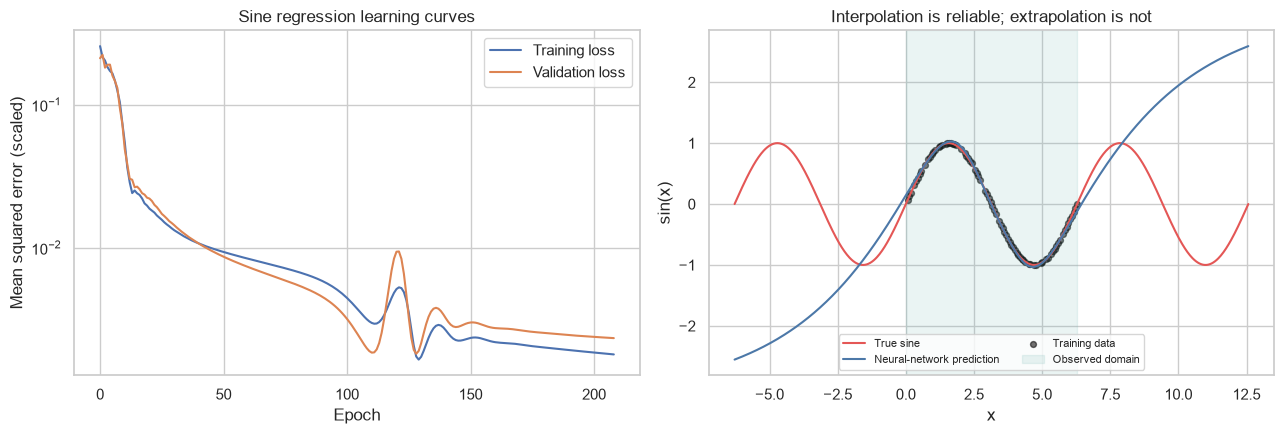

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(regression_history.history["loss"], label="Training loss")
axes[0].plot(regression_history.history["val_loss"], label="Validation loss")
axes[0].set(
    title="Sine regression learning curves",
    xlabel="Epoch",
    ylabel="Mean squared error (scaled)",
    yscale="log",
)
axes[0].legend()

axes[1].plot(x_extrapolation, np.sin(x_extrapolation), label="True sine", color="#E45756")
axes[1].plot(
    x_extrapolation,
    y_extrapolation_prediction,
    label="Neural-network prediction",
    color="#4C78A8",
)
axes[1].scatter(x_reg_train, y_reg_train, s=18, color="black", alpha=0.55, label="Training data")
axes[1].axvspan(0, 2 * np.pi, color="#72B7B2", alpha=0.15, label="Observed domain")
axes[1].set(
    title="Interpolation is reliable; extrapolation is not",
    xlabel="x",
    ylabel="sin(x)",
)
axes[1].legend(loc="lower center", ncol=2, fontsize=8)

plt.tight_layout()
plt.show()

The network is evaluated separately inside and outside the observed domain. A low
interpolation error does not imply that a generic Dense network has learned the periodic
rule; extrapolation reveals that limitation directly.

## Study 2 - MNIST Handwritten-Digit Classification

In [6]:
(mnist_images_full, mnist_labels_full), (mnist_test_images, mnist_test_labels) = (
    keras.datasets.mnist.load_data()
)

mnist_train_images, mnist_validation_images, mnist_train_labels, mnist_validation_labels = (
    train_test_split(
        mnist_images_full,
        mnist_labels_full,
        test_size=10_000,
        stratify=mnist_labels_full,
        random_state=RANDOM_STATE,
    )
)

mnist_train_images = mnist_train_images.astype("float32") / 255.0
mnist_validation_images = mnist_validation_images.astype("float32") / 255.0
mnist_test_images = mnist_test_images.astype("float32") / 255.0

mnist_profile = pd.Series(
    {
        "training_rows": len(mnist_train_images),
        "validation_rows": len(mnist_validation_images),
        "test_rows": len(mnist_test_images),
        "image_shape": str(mnist_train_images.shape[1:]),
        "classes": int(np.unique(mnist_train_labels).size),
        "minimum_pixel": float(mnist_train_images.min()),
        "maximum_pixel": float(mnist_train_images.max()),
    }
)
mnist_profile

training_rows         50000
validation_rows       10000
test_rows             10000
image_shape        (28, 28)
classes                  10
minimum_pixel           0.0
maximum_pixel           1.0
dtype: object

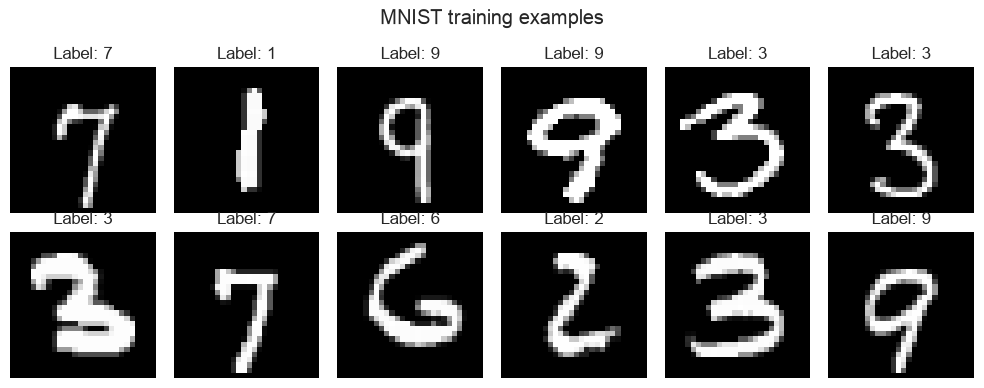

In [7]:
fig, axes = plt.subplots(2, 6, figsize=(10, 4))
for ax, image, label in zip(axes.ravel(), mnist_train_images[:12], mnist_train_labels[:12]):
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")
plt.suptitle("MNIST training examples")
plt.tight_layout()
plt.show()

In [8]:
mnist_model = keras.Sequential(
    [
        keras.Input(shape=(28, 28)),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.20),
        layers.Dense(10, activation="softmax"),
    ],
    name="mnist_dense_classifier",
)
mnist_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

mnist_history = mnist_model.fit(
    mnist_train_images,
    mnist_train_labels,
    validation_data=(mnist_validation_images, mnist_validation_labels),
    epochs=8,
    batch_size=128,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=2,
            restore_best_weights=True,
        )
    ],
    verbose=2,
)

print("Trainable parameters:", mnist_model.count_params())

Epoch 1/8


391/391 - 1s - 2ms/step - accuracy: 0.8764 - loss: 0.4291 - val_accuracy: 0.9358 - val_loss: 0.2257


Epoch 2/8


391/391 - 0s - 1ms/step - accuracy: 0.9395 - loss: 0.2082 - val_accuracy: 0.9521 - val_loss: 0.1669


Epoch 3/8


...

Epoch 7/8


391/391 - 0s - 1ms/step - accuracy: 0.9747 - loss: 0.0840 - val_accuracy: 0.9726 - val_loss: 0.0940


Epoch 8/8


391/391 - 0s - 1ms/step - accuracy: 0.9759 - loss: 0.0782 - val_accuracy: 0.9734 - val_loss: 0.0914


Trainable parameters: 101770


In [9]:
mnist_test_loss, mnist_test_accuracy = mnist_model.evaluate(
    mnist_test_images, mnist_test_labels, verbose=0
)
mnist_probabilities = mnist_model.predict(mnist_test_images, batch_size=256, verbose=0)
mnist_predictions = mnist_probabilities.argmax(axis=1)
mnist_sklearn_log_loss = log_loss(
    mnist_test_labels,
    mnist_probabilities,
    labels=np.arange(10),
)

assert np.isclose(
    mnist_test_accuracy,
    accuracy_score(mnist_test_labels, mnist_predictions),
)
assert np.isclose(mnist_test_loss, mnist_sklearn_log_loss, atol=1e-5)

pd.Series(
    {
        "test_cross_entropy": mnist_test_loss,
        "sklearn_log_loss_check": mnist_sklearn_log_loss,
        "test_accuracy": mnist_test_accuracy,
        "correct_predictions": int((mnist_predictions == mnist_test_labels).sum()),
        "test_rows": len(mnist_test_labels),
    }
)

test_cross_entropy            0.0858
sklearn_log_loss_check        0.0858
test_accuracy                 0.9739
correct_predictions        9739.0000
test_rows                 10000.0000
dtype: float64

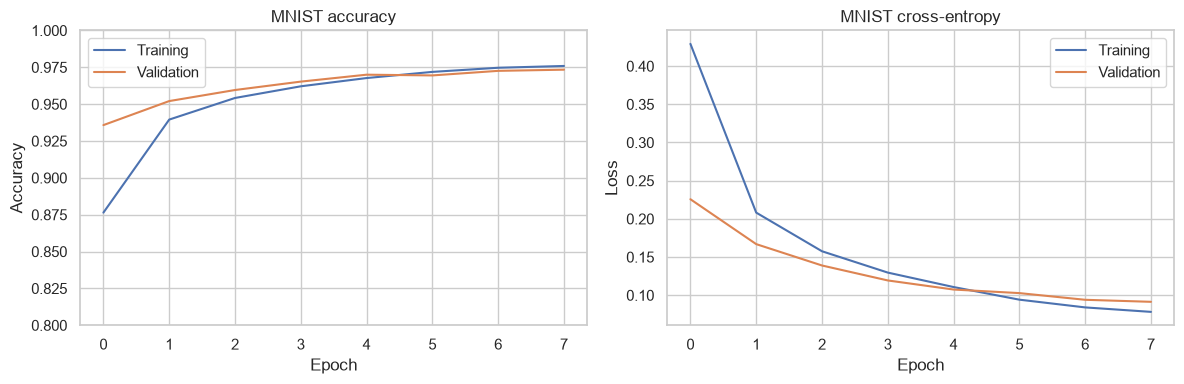

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(mnist_history.history["accuracy"], label="Training")
axes[0].plot(mnist_history.history["val_accuracy"], label="Validation")
axes[0].set(title="MNIST accuracy", xlabel="Epoch", ylabel="Accuracy", ylim=(0.8, 1.0))
axes[0].legend()

axes[1].plot(mnist_history.history["loss"], label="Training")
axes[1].plot(mnist_history.history["val_loss"], label="Validation")
axes[1].set(title="MNIST cross-entropy", xlabel="Epoch", ylabel="Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

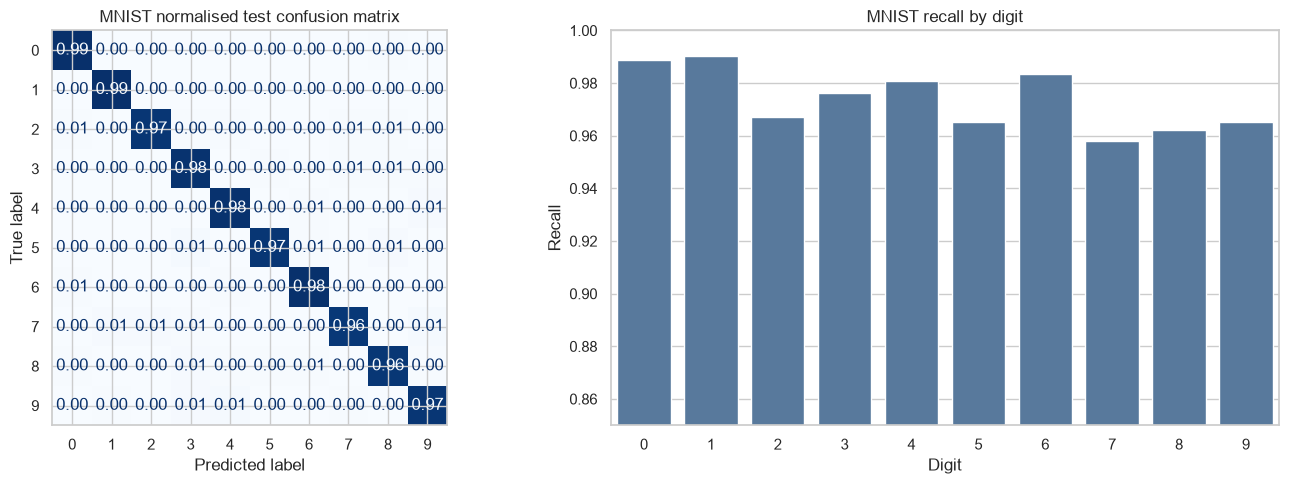

,digit,test_recall
0,0,0.9888
1,1,0.9903
2,2,0.9671
3,3,0.9762
4,4,0.9807
5,5,0.9652
6,6,0.9833
7,7,0.9582
8,8,0.9620
9,9,0.9653


In [11]:
mnist_class_recall = recall_score(
    mnist_test_labels,
    mnist_predictions,
    labels=np.arange(10),
    average=None,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(
    mnist_test_labels,
    mnist_predictions,
    labels=np.arange(10),
    normalize="true",
    cmap="Blues",
    values_format=".2f",
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title("MNIST normalised test confusion matrix")

sns.barplot(x=np.arange(10), y=mnist_class_recall, color="#4C78A8", ax=axes[1])
axes[1].set(
    title="MNIST recall by digit",
    xlabel="Digit",
    ylabel="Recall",
    ylim=(0.85, 1.0),
)

plt.tight_layout()
plt.show()

pd.DataFrame({"digit": np.arange(10), "test_recall": mnist_class_recall}).round(4)

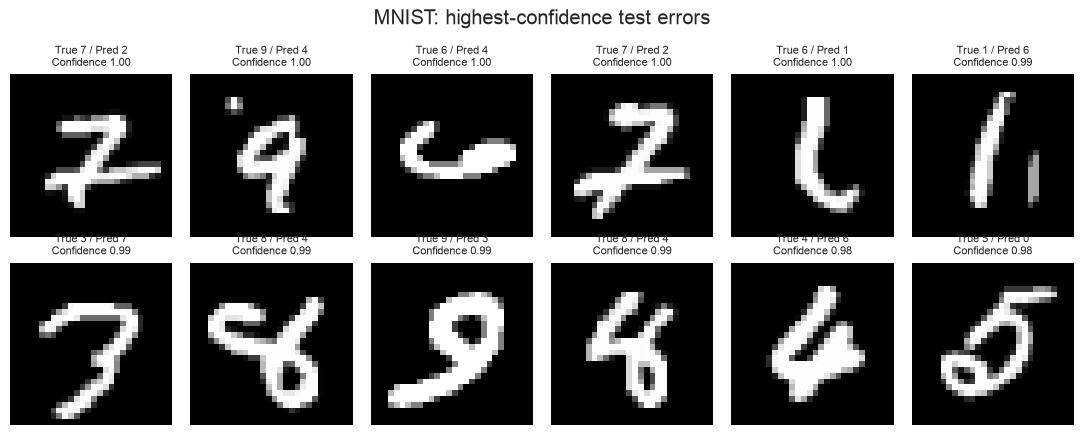

In [12]:
mnist_error_indices = np.flatnonzero(mnist_predictions != mnist_test_labels)
mnist_error_confidence = mnist_probabilities[mnist_error_indices].max(axis=1)
mnist_high_confidence_errors = mnist_error_indices[
    np.argsort(mnist_error_confidence)[-12:][::-1]
]

fig, axes = plt.subplots(2, 6, figsize=(11, 4.5))
for ax, index in zip(axes.ravel(), mnist_high_confidence_errors):
    ax.imshow(mnist_test_images[index], cmap="gray")
    ax.set_title(
        f"True {mnist_test_labels[index]} / Pred {mnist_predictions[index]}\n"
        f"Confidence {mnist_probabilities[index].max():.2f}",
        fontsize=8,
    )
    ax.axis("off")
plt.suptitle("MNIST: highest-confidence test errors")
plt.tight_layout()
plt.show()

## Study 3 - CIFAR-10 Dense Baseline

In [13]:
cifar_local_archive = os.getenv("CIFAR10_LOCAL_ARCHIVE")

if cifar_local_archive:
    with np.load(cifar_local_archive) as cifar_archive:
        cifar_images_full = cifar_archive["train_images"]
        cifar_labels_full = cifar_archive["train_labels"]
        cifar_test_images = cifar_archive["test_images"]
        cifar_test_labels = cifar_archive["test_labels"]
    cifar_data_source = "University of Toronto Hugging Face mirror (local validation cache)"
else:
    (cifar_images_full, cifar_labels_full), (cifar_test_images, cifar_test_labels) = (
        keras.datasets.cifar10.load_data()
    )
    cifar_data_source = "tensorflow.keras.datasets.cifar10"

cifar_labels_full = cifar_labels_full.ravel()
cifar_test_labels = cifar_test_labels.ravel()

cifar_pool_indices = np.arange(len(cifar_images_full))
cifar_development_indices, _ = train_test_split(
    cifar_pool_indices,
    train_size=7_000,
    stratify=cifar_labels_full,
    random_state=RANDOM_STATE,
)
cifar_train_indices, cifar_validation_indices = train_test_split(
    cifar_development_indices,
    test_size=1_000,
    stratify=cifar_labels_full[cifar_development_indices],
    random_state=RANDOM_STATE,
)

cifar_train_images = cifar_images_full[cifar_train_indices]
cifar_train_labels = cifar_labels_full[cifar_train_indices]
cifar_validation_images = cifar_images_full[cifar_validation_indices]
cifar_validation_labels = cifar_labels_full[cifar_validation_indices]
cifar_available_training_rows = len(cifar_images_full)
del cifar_images_full, cifar_labels_full

cifar_train_images = cifar_train_images.astype("float32") / 255.0
cifar_validation_images = cifar_validation_images.astype("float32") / 255.0
cifar_test_images = cifar_test_images.astype("float32") / 255.0

cifar_class_names = np.array(
    ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]
)

cifar_profile = pd.Series(
    {
        "training_rows": len(cifar_train_images),
        "validation_rows": len(cifar_validation_images),
        "test_rows": len(cifar_test_images),
        "available_training_pool_rows": cifar_available_training_rows,
        "image_shape": str(cifar_train_images.shape[1:]),
        "classes": int(np.unique(cifar_train_labels).size),
        "minimum_pixel": float(cifar_train_images.min()),
        "maximum_pixel": float(cifar_train_images.max()),
        "data_source": cifar_data_source,
    }
)
cifar_profile

training_rows                                                                6000
validation_rows                                                              1000
test_rows                                                                   10000
available_training_pool_rows                                                50000
image_shape                                                           (32, 32, 3)
classes                                                                        10
minimum_pixel                                                                 0.0
maximum_pixel                                                                 1.0
data_source                     University of Toronto Hugging Face mirror (loc...
dtype: object

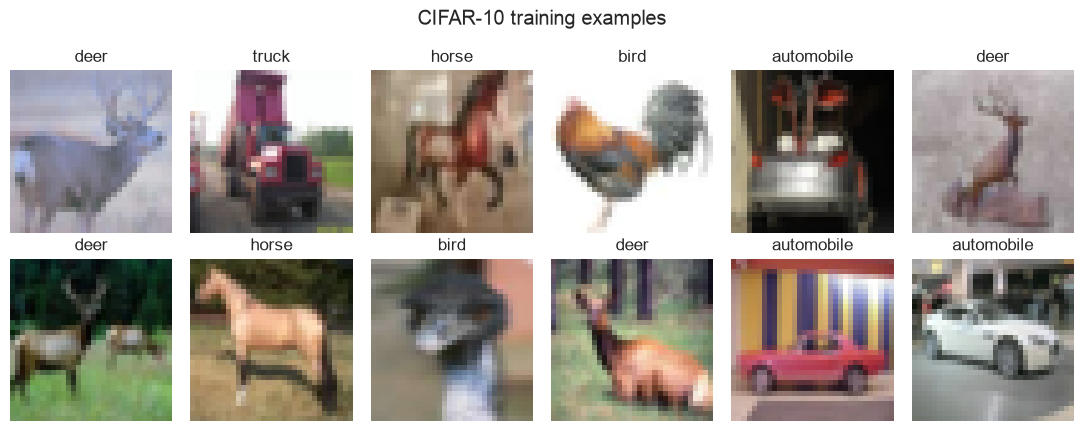

In [14]:
fig, axes = plt.subplots(2, 6, figsize=(11, 4.5))
for ax, image, label in zip(axes.ravel(), cifar_train_images[:12], cifar_train_labels[:12]):
    ax.imshow(image)
    ax.set_title(cifar_class_names[label])
    ax.axis("off")
plt.suptitle("CIFAR-10 training examples")
plt.tight_layout()
plt.show()

In [15]:
cifar_model = keras.Sequential(
    [
        keras.Input(shape=(32, 32, 3)),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.30),
        layers.Dense(10, activation="softmax"),
    ],
    name="cifar10_dense_baseline",
)
cifar_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

cifar_history = cifar_model.fit(
    cifar_train_images,
    cifar_train_labels,
    validation_data=(cifar_validation_images, cifar_validation_labels),
    epochs=5,
    batch_size=512,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=1,
            restore_best_weights=True,
        )
    ],
    verbose=2,
)

print("Trainable parameters:", cifar_model.count_params())

Epoch 1/5


12/12 - 0s - 40ms/step - accuracy: 0.1328 - loss: 2.4468 - val_accuracy: 0.1920 - val_loss: 2.2446


Epoch 2/5


12/12 - 0s - 6ms/step - accuracy: 0.1558 - loss: 2.2411 - val_accuracy: 0.1890 - val_loss: 2.2141


Epoch 3/5


...

Epoch 4/5


12/12 - 0s - 6ms/step - accuracy: 0.1860 - loss: 2.1924 - val_accuracy: 0.2140 - val_loss: 2.1735


Epoch 5/5


12/12 - 0s - 6ms/step - accuracy: 0.1933 - loss: 2.1768 - val_accuracy: 0.2310 - val_loss: 2.1472


Trainable parameters: 197322


In [16]:
cifar_test_loss, cifar_test_accuracy = cifar_model.evaluate(
    cifar_test_images, cifar_test_labels, batch_size=512, verbose=0
)
cifar_probabilities = cifar_model.predict(cifar_test_images, batch_size=512, verbose=0)
cifar_predictions = cifar_probabilities.argmax(axis=1)
cifar_sklearn_log_loss = log_loss(
    cifar_test_labels,
    cifar_probabilities,
    labels=np.arange(10),
)

assert np.isclose(
    cifar_test_accuracy,
    accuracy_score(cifar_test_labels, cifar_predictions),
)
assert np.isclose(cifar_test_loss, cifar_sklearn_log_loss, atol=1e-5)

pd.Series(
    {
        "test_cross_entropy": cifar_test_loss,
        "sklearn_log_loss_check": cifar_sklearn_log_loss,
        "test_accuracy": cifar_test_accuracy,
        "correct_predictions": int((cifar_predictions == cifar_test_labels).sum()),
        "test_rows": len(cifar_test_labels),
        "chance_accuracy": 0.10,
    }
)

test_cross_entropy            2.1533
sklearn_log_loss_check        2.1533
test_accuracy                 0.2290
correct_predictions        2290.0000
test_rows                 10000.0000
chance_accuracy               0.1000
dtype: float64

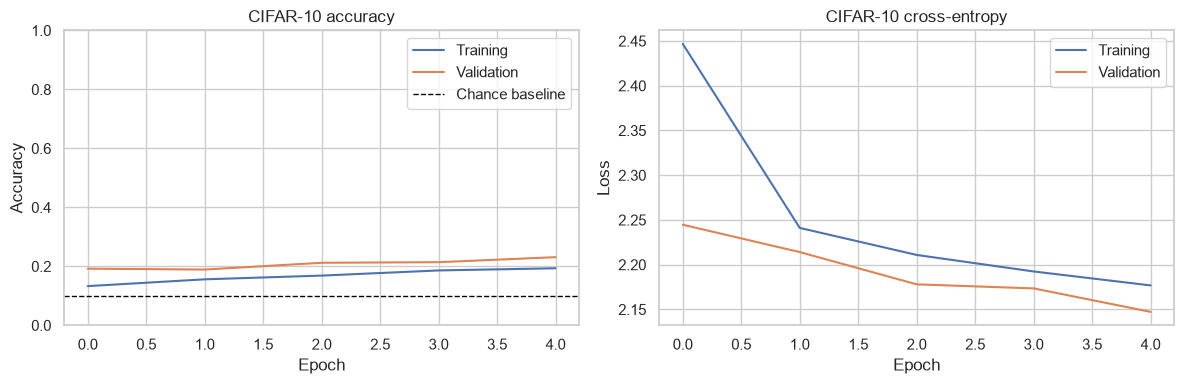

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(cifar_history.history["accuracy"], label="Training")
axes[0].plot(cifar_history.history["val_accuracy"], label="Validation")
axes[0].axhline(0.10, color="black", linestyle="--", linewidth=1, label="Chance baseline")
axes[0].set(title="CIFAR-10 accuracy", xlabel="Epoch", ylabel="Accuracy", ylim=(0, 1))
axes[0].legend()

axes[1].plot(cifar_history.history["loss"], label="Training")
axes[1].plot(cifar_history.history["val_loss"], label="Validation")
axes[1].set(title="CIFAR-10 cross-entropy", xlabel="Epoch", ylabel="Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

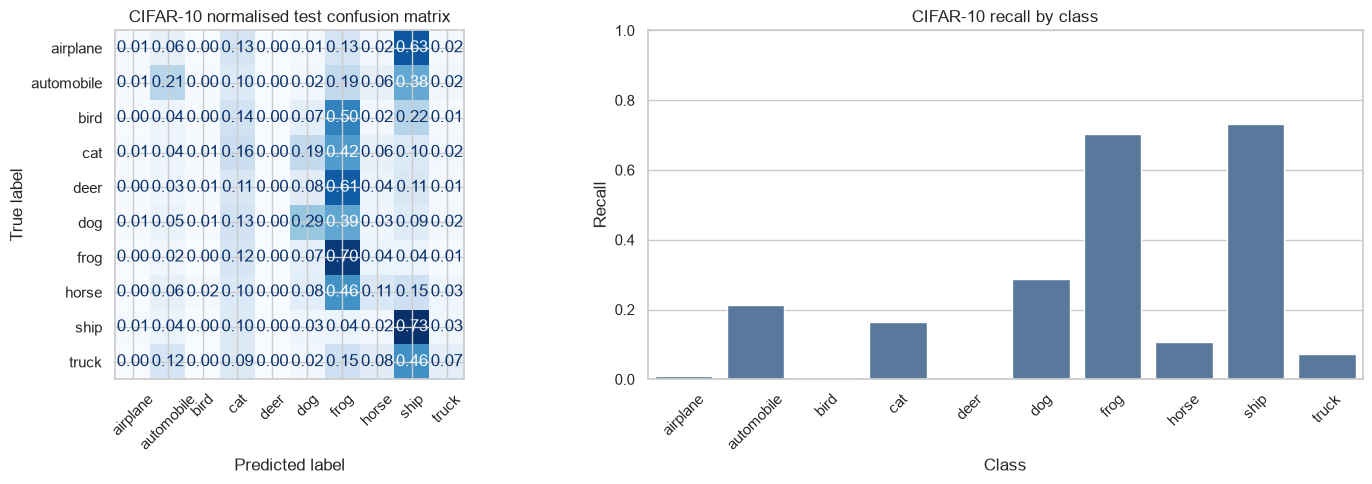

,class,test_recall
0,airplane,0.008
1,automobile,0.214
2,bird,0.004
3,cat,0.163
4,deer,0.001
5,dog,0.287
6,frog,0.703
7,horse,0.106
8,ship,0.732
9,truck,0.072


In [18]:
cifar_class_recall = recall_score(
    cifar_test_labels,
    cifar_predictions,
    labels=np.arange(10),
    average=None,
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ConfusionMatrixDisplay.from_predictions(
    cifar_test_labels,
    cifar_predictions,
    labels=np.arange(10),
    display_labels=cifar_class_names,
    normalize="true",
    cmap="Blues",
    values_format=".2f",
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title("CIFAR-10 normalised test confusion matrix")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(x=cifar_class_names, y=cifar_class_recall, color="#4C78A8", ax=axes[1])
axes[1].set(
    title="CIFAR-10 recall by class",
    xlabel="Class",
    ylabel="Recall",
    ylim=(0, 1),
)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

pd.DataFrame({"class": cifar_class_names, "test_recall": cifar_class_recall}).round(4)

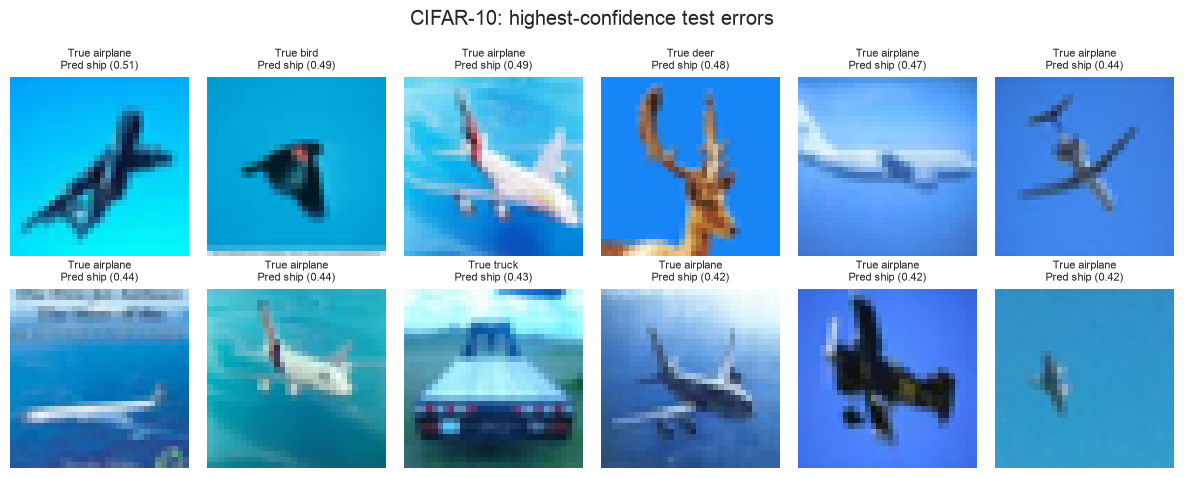

In [19]:
cifar_error_indices = np.flatnonzero(cifar_predictions != cifar_test_labels)
cifar_error_confidence = cifar_probabilities[cifar_error_indices].max(axis=1)
cifar_high_confidence_errors = cifar_error_indices[
    np.argsort(cifar_error_confidence)[-12:][::-1]
]

fig, axes = plt.subplots(2, 6, figsize=(12, 5))
for ax, index in zip(axes.ravel(), cifar_high_confidence_errors):
    ax.imshow(cifar_test_images[index])
    ax.set_title(
        f"True {cifar_class_names[cifar_test_labels[index]]}\n"
        f"Pred {cifar_class_names[cifar_predictions[index]]} "
        f"({cifar_probabilities[index].max():.2f})",
        fontsize=8,
    )
    ax.axis("off")
plt.suptitle("CIFAR-10: highest-confidence test errors")
plt.tight_layout()
plt.show()

## Results Summary

In [20]:
final_metrics = pd.DataFrame(
    [
        {
            "study": "Sine regression",
            "model": "Two-hidden-layer Dense network",
            "test_scope": "Interpolation grid",
            "primary_metric": "RMSE",
            "value": interpolation_rmse,
        },
        {
            "study": "Sine regression",
            "model": "Two-hidden-layer Dense network",
            "test_scope": "Wide extrapolation grid",
            "primary_metric": "RMSE",
            "value": extrapolation_rmse,
        },
        {
            "study": "MNIST",
            "model": "Dense classifier",
            "test_scope": "10,000-image test set",
            "primary_metric": "Accuracy",
            "value": mnist_test_accuracy,
        },
        {
            "study": "CIFAR-10",
            "model": "Dense baseline",
            "test_scope": "10,000-image test set",
            "primary_metric": "Accuracy",
            "value": cifar_test_accuracy,
        },
    ]
)
final_metrics.round(4)

,study,model,test_scope,primary_metric,value
0,Sine regression,Two-hidden-layer Dense network,Interpolation grid,RMSE,0.0377
1,Sine regression,Two-hidden-layer Dense network,Wide extrapolation grid,RMSE,1.7004
2,MNIST,Dense classifier,"10,000-image test set",Accuracy,0.9739
3,CIFAR-10,Dense baseline,"10,000-image test set",Accuracy,0.2290


## Takeaways

1. **Interpolation and extrapolation are different problems.** The sine network can fit the
   observed range well while failing outside it; a low in-range error is not evidence that
   the periodic rule has been recovered.
2. **Correct evaluation structure matters.** MNIST and CIFAR-10 use separate validation data
   for training decisions and untouched test data for the final metrics.
3. **Baselines expose architecture limits.** Flattening CIFAR-10 is computationally simple,
   but it discards spatial structure. A CNN is the appropriate next experiment when accelerated
   hardware is available.
4. **Aggregate accuracy is incomplete.** Per-class recall and high-confidence errors reveal
   which classes remain difficult and where the models are confidently wrong.

### Limitations and next steps

- The goal is a compact CPU-runnable learning project, not an exhaustive architecture search.
- No hyperparameter search or repeated neural-network training is performed, so optimisation
  uncertainty is not estimated.
- The CIFAR-10 model is deliberately a lightweight Dense baseline trained on a stratified
  6,000-image subset and evaluated on the full 10,000-image test set.
- CIFAR-10 performance should be improved next with convolutional layers, augmentation,
  learning-rate schedules, and accelerated hardware.
- Calibration, robustness to distribution shift, and fairness are outside this project's scope.
- Cloud setup should become a separate project only after a reproducible AWS or Azure run is
  available with configuration, costs, metrics, and resource-cleanup evidence.